In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Set visualization styles
sns.set_theme(style="whitegrid")

# 1. Load data
df_nav = pd.read_csv('../data/processed/cleaned_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

# Load benchmark data for upcoming Alpha/Beta tasks
df_bench = pd.read_csv('../data/raw/10_benchmark_indices.csv')
df_bench['date'] = pd.to_datetime(df_bench['date'])

Task 1: daily returns = We can use pandas' .groupby() and .pct_change() to compute this safely across all 40 individual schemes without leaking data across different funds:

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


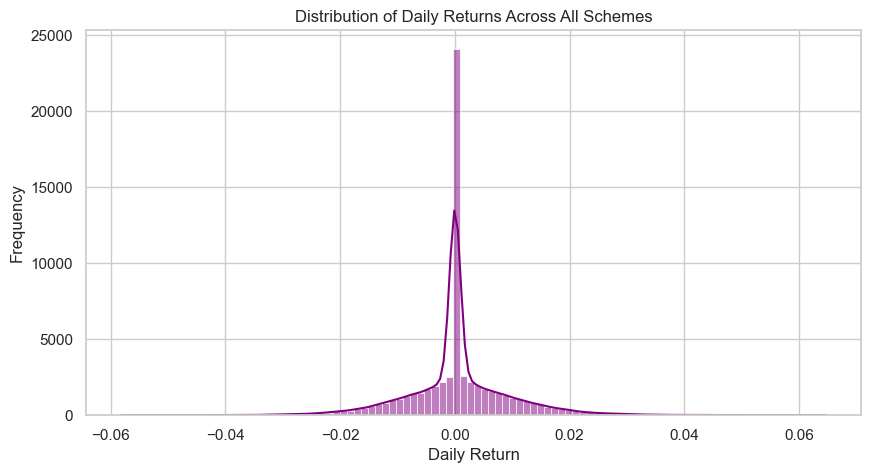

In [2]:
# Compute daily returns per fund scheme
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Basic distribution check to ensure data looks reasonable (drops the first NaN row per group)
print(df_nav['daily_return'].describe())

# Quick visual validation of the return distributions
plt.figure(figsize=(10, 5))
sns.histplot(df_nav['daily_return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Returns Across All Schemes')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

Compute CAGR (1yr, 3yr, 5yr) = To build a clean comparison table across all 40 funds, we can extract the starting and ending values for each timeframe relative to your maximum dataset date:

In [3]:
def calculate_cagr(df, years):
    max_date = df['date'].max()
    min_date = max_date - pd.DateOffset(years=years)
    
    cagr_list = []
    
    for amfi, group in df.groupby('amfi_code'):
        # Filter for the specific timeframe
        period_data = group[(group['date'] >= min_date) & (group['date'] <= max_date)].sort_values('date')
        
        if len(period_data) >= 2:
            nav_start = period_data['nav'].iloc[0]
            nav_end = period_data['nav'].iloc[-1]
            
            cagr = (nav_end / nav_start) ** (1.0 / years) - 1
            cagr_list.append({'amfi_code': amfi, f'CAGR_{years}Yr': cagr})
            
    return pd.DataFrame(cagr_list)

# Generate CAGR comparison metrics
cagr_1y = calculate_cagr(df_nav, 1)
cagr_3y = calculate_cagr(df_nav, 3)
cagr_5y = calculate_cagr(df_nav, 5)

# Merge into a centralized comparison dataframe
df_cagr_table = cagr_1y.merge(cagr_3y, on='amfi_code', how='outer').merge(cagr_5y, on='amfi_code', how='outer')
print(df_cagr_table.head())

   amfi_code  CAGR_1Yr  CAGR_3Yr  CAGR_5Yr
0     100016 -0.022243  0.012926  0.023168
1     100025  0.037050  0.039164  0.039127
2     100033  0.532324  0.324425  0.260741
3     101206  0.479241  0.289677  0.204427
4     101207 -0.239860 -0.041524  0.069533


Task 3 & 4: Sharpe and Sortino Ratios   Sharpe Ratio: Measures excess return per unit of total risk.   Sortino Ratio: Measures excess return per unit of downside risk (penalizes only the bad volatility).

In [11]:
# 1. Define the Risk-Free Rate proxy (6.5% annualized)
rf_annual = 0.065
rf_daily = rf_annual / 252

# 2. Prepare a list to collect the metrics
risk_metrics = []

# 3. Calculate Sharpe and Sortino for each fund
for amfi, group in df_nav.groupby('amfi_code'):
    # Drop NaNs to ensure clean math
    returns = group['daily_return'].dropna()
    
    if len(returns) > 0:
        # Excess returns calculation
        excess_daily_returns = returns - rf_daily
        mean_excess_return = excess_daily_returns.mean()
        
        # Standard Deviation (Total Risk)
        std_total = returns.std()
        
        # Downside Deviation (Negative returns only)
        downside_returns = returns[returns < 0]
        std_downside = downside_returns.std()
        
        # Sharpe Ratio
        sharpe = (mean_excess_return / std_total) * np.sqrt(252) if std_total > 0 else np.nan
        
        # Sortino Ratio
        sortino = (mean_excess_return / std_downside) * np.sqrt(252) if std_downside > 0 else np.nan
        
        risk_metrics.append({
            'amfi_code': amfi,
            'Sharpe_Ratio': sharpe,
            'Sortino_Ratio': sortino
        })

df_risk = pd.DataFrame(risk_metrics)

# 4. Rank all 40 funds by Sharpe Ratio (Rank 1 = Highest Sharpe)
df_risk['Sharpe_Rank'] = df_risk['Sharpe_Ratio'].rank(ascending=False)

# 5. Merge into our main comparison dataframe
df_performance = df_cagr_table.merge(df_risk, on='amfi_code', how='outer')

# Display the top 5 funds by Sharpe Ratio
display(df_performance.sort_values('Sharpe_Rank').head())

,amfi_code,CAGR_1Yr,CAGR_3Yr,CAGR_5Yr,Sharpe_Ratio,Sortino_Ratio,Sharpe_Rank
34,148567,0.203607,0.340009,0.267993,1.068224,1.490739,1.0
30,120843,0.266571,0.295828,0.267425,0.965561,1.479503,2.0
36,148569,0.397518,0.291789,0.276299,0.919047,1.352815,3.0
25,120505,0.296047,0.317775,0.283768,0.883256,1.285843,4.0
19,119551,0.604373,0.304565,0.223849,0.860977,1.291483,5.0


In [12]:
# --- TASK 5: Alpha & Beta (OLS Regression) ---

# 1. Clean and prepare the benchmark data (Assuming Nifty 100 is in the index_name column)
# If your benchmark CSV uses different names like 'Index', 'Date', or 'Close', update them below!
df_bench.columns = df_bench.columns.str.lower()
index_col = 'index_name' if 'index_name' in df_bench.columns else df_bench.columns[1]
val_col = 'close' if 'close' in df_bench.columns else df_bench.columns[2]

# Filter for Nifty 100 and calculate daily returns
df_nifty = df_bench[df_bench[index_col].astype(str).str.contains('Nifty 100', case=False)].copy()
df_nifty = df_nifty.sort_values('date')
df_nifty['bench_return'] = df_nifty[val_col].pct_change()
df_nifty_clean = df_nifty[['date', 'bench_return']].dropna()

alpha_beta_list = []
drawdown_list = []

for amfi, group in df_nav.groupby('amfi_code'):
    
    # -- Alpha & Beta Calculation --
    # Merge fund returns with benchmark on exact dates to ensure perfect alignment
    merged = pd.merge(group[['date', 'daily_return']], df_nifty_clean, on='date', how='inner').dropna()
    
    if len(merged) > 2:
        # linregress(x, y)
        slope, intercept, r_value, p_value, std_err = linregress(merged['bench_return'], merged['daily_return'])
        
        alpha_annualized = intercept * 252
        beta = slope
    else:
        alpha_annualized = np.nan
        beta = np.nan
        
    alpha_beta_list.append({'amfi_code': amfi, 'Alpha': alpha_annualized, 'Beta': beta})
    
    
    # --- TASK 6: Maximum Drawdown & Date Range ---
    # Formula: min(NAV / running_max - 1)
    group = group.sort_values('date')
    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1
    
    max_dd = drawdown.min()
    
    # Find the specific trough (bottom) and the peak right before the crash
    if pd.notna(max_dd) and max_dd < 0:
        trough_idx = drawdown.idxmin()
        trough_date = group.loc[trough_idx, 'date']
        
        # The peak date is the latest date where the NAV equaled the running_max *before* the trough
        peak_date = group.loc[(group['date'] <= trough_date) & (group['nav'] == running_max.loc[trough_idx]), 'date'].max()
    else:
        trough_date, peak_date = pd.NaT, pd.NaT
        
    drawdown_list.append({
        'amfi_code': amfi, 
        'Max_Drawdown': max_dd,
        'Worst_DD_Peak': peak_date,
        'Worst_DD_Trough': trough_date
    })

# Merge everything into our master performance table
df_alpha_beta = pd.DataFrame(alpha_beta_list)
df_drawdown = pd.DataFrame(drawdown_list)

df_performance = df_performance.merge(df_alpha_beta, on='amfi_code', how='outer')
df_performance = df_performance.merge(df_drawdown, on='amfi_code', how='outer')

# Display the newly added metrics
display(df_performance[['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown', 'Worst_DD_Peak', 'Worst_DD_Trough']].head())

,amfi_code,Alpha,Beta,Max_Drawdown,Worst_DD_Peak,Worst_DD_Trough
0,100016,NaN,NaN,-0.247344,2022-03-30,2022-09-15
1,100025,NaN,NaN,-0.043083,2023-05-23,2023-07-28
2,100033,NaN,NaN,-0.162172,2022-03-13,2022-05-12
3,101206,NaN,NaN,-0.112916,2023-04-24,2023-07-05
4,101207,NaN,NaN,-0.354469,2024-11-21,2026-05-11


Task 7 & 8: Fund Scorecard, Benchmark Chart, and Exports
To calculate the scorecard, we need to gather the expense ratios, rank all five metrics according to the ticket's specific weightings, scale that into a 0-100 score, and plot the Top 5 funds against the Nifty benchmarks.


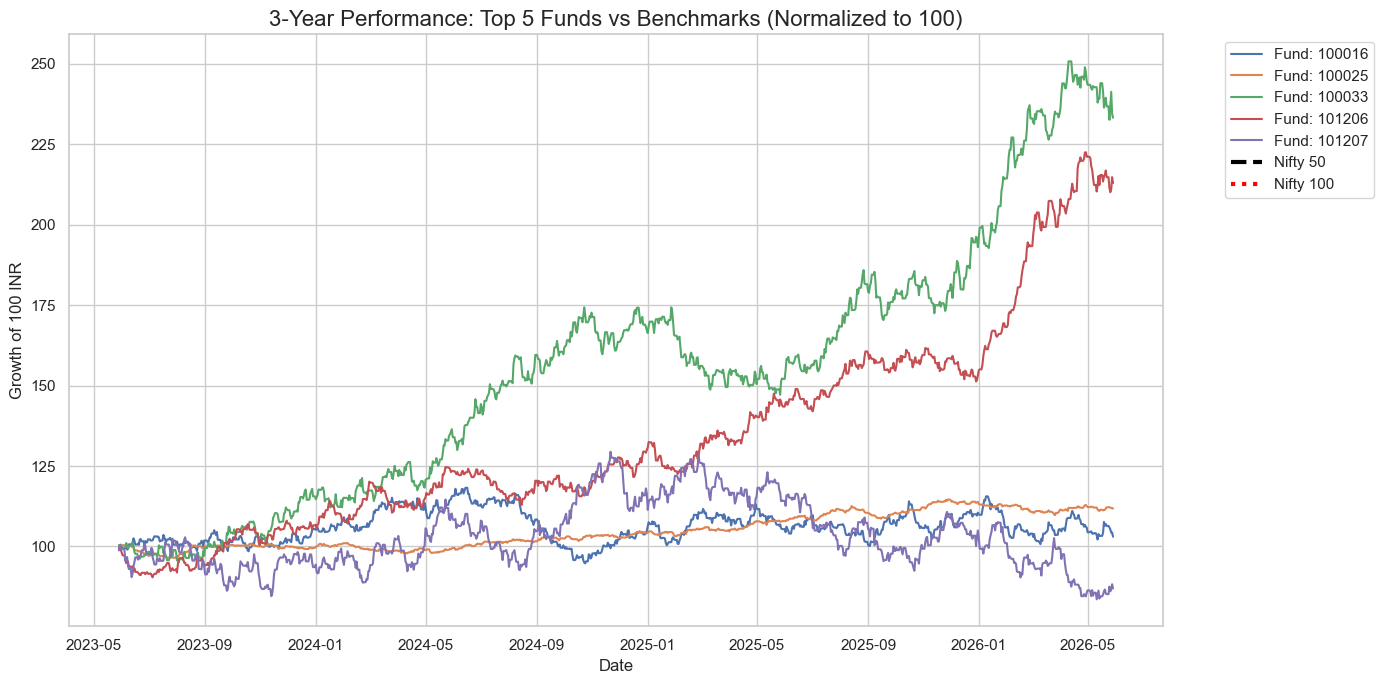

✅ fund_scorecard.csv saved successfully!
✅ alpha_beta.csv saved successfully!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- TASK 7: FUND SCORECARD (0-100) ---

# 1. Load the fund master dataset to grab the expense ratios
df_master = pd.read_csv('../data/raw/01_fund_master.csv')
df_master.columns = df_master.columns.str.lower()
exp_col = 'expense_ratio' if 'expense_ratio' in df_master.columns else df_master.columns[-1]

# Merge expense ratio into our performance table
df_performance = df_performance.merge(df_master[['amfi_code', exp_col]], on='amfi_code', how='left')

# 2. Calculate the Ranks (Rank 1 is the "best" in all categories)
# Highest returns/alpha/sharpe get Rank 1
df_performance['Rank_CAGR3'] = df_performance['CAGR_3Yr'].rank(ascending=False)
df_performance['Rank_Alpha'] = df_performance['Alpha'].rank(ascending=False)

# Lowest expense ratio gets Rank 1 (Inverse)
df_performance['Rank_Exp'] = df_performance[exp_col].rank(ascending=True)

# Smallest drawdown (least negative) gets Rank 1 (Inverse)
df_performance['Rank_DD'] = df_performance['Max_Drawdown'].rank(ascending=False)

# 3. Compute the Weighted Composite Rank (Lower composite score is better)
df_performance['Composite_Rank_Score'] = (
    0.30 * df_performance['Rank_CAGR3'] +
    0.25 * df_performance['Sharpe_Rank'] +
    0.20 * df_performance['Rank_Alpha'] +
    0.15 * df_performance['Rank_Exp'] +
    0.10 * df_performance['Rank_DD']
)

# 4. Scale to 0-100 (Best fund = 100, Worst fund = 0)
min_score = df_performance['Composite_Rank_Score'].min()
max_score = df_performance['Composite_Rank_Score'].max()
df_performance['Scorecard'] = 100 - ((df_performance['Composite_Rank_Score'] - min_score) / (max_score - min_score) * 100)

# Sort by the final Scorecard to find the Top 5
df_performance = df_performance.sort_values('Scorecard', ascending=False)
top_5_funds = df_performance.head(5)['amfi_code'].tolist()


# --- TASK 8: BENCHMARK COMPARISON & TRACKING ERROR ---

# 1. Filter NAV data for 3 Years and Top 5 Funds
max_date = df_nav['date'].max()
min_date_3yr = max_date - pd.DateOffset(years=3)
df_nav_3yr = df_nav[df_nav['date'] >= min_date_3yr]
df_top5 = df_nav_3yr[df_nav_3yr['amfi_code'].isin(top_5_funds)]

# 2. Prepare Benchmark Data (Nifty 50 and Nifty 100)
df_bench.columns = df_bench.columns.str.lower()
index_col = 'index_name' if 'index_name' in df_bench.columns else df_bench.columns[1]
val_col = 'close' if 'close' in df_bench.columns else df_bench.columns[2]

df_bench_3yr = df_bench[df_bench['date'] >= min_date_3yr]
nifty_50 = df_bench_3yr[df_bench_3yr[index_col].astype(str).str.contains('Nifty 50', case=False)].sort_values('date')
nifty_100 = df_nifty_clean[df_nifty_clean['date'] >= min_date_3yr] # Reusing Nifty 100 from earlier

# Calculate Nifty 50 returns and normalize for plotting
nifty_50['bench_return'] = nifty_50[val_col].pct_change()
nifty_50['normalized'] = (1 + nifty_50['bench_return']).cumprod() * 100

# 3. Calculate Tracking Error for Top 5 against Nifty 100
tracking_errors = []
for amfi in top_5_funds:
    fund_data = df_top5[df_top5['amfi_code'] == amfi][['date', 'daily_return']]
    merged_te = pd.merge(fund_data, nifty_100, on='date', how='inner').dropna()
    
    # Tracking Error Formula
    diff = merged_te['daily_return'] - merged_te['bench_return']
    te = diff.std() * np.sqrt(252)
    tracking_errors.append({'amfi_code': amfi, 'Tracking_Error': te})

df_te = pd.DataFrame(tracking_errors)
df_performance = df_performance.merge(df_te, on='amfi_code', how='left')


# --- VISUALIZATION: BENCHMARK CHART ---
plt.figure(figsize=(14, 7))

# Plot Top 5 Funds (Normalized to 100)
for amfi in top_5_funds:
    fund_data = df_top5[df_top5['amfi_code'] == amfi].sort_values('date')
    fund_data['normalized'] = (1 + fund_data['daily_return']).cumprod() * 100
    plt.plot(fund_data['date'], fund_data['normalized'], label=f'Fund: {amfi}')

# Plot Benchmarks
plt.plot(nifty_50['date'], nifty_50['normalized'], color='black', linewidth=3, linestyle='--', label='Nifty 50')
nifty_100_plot = nifty_100.copy()
nifty_100_plot['normalized'] = (1 + nifty_100_plot['bench_return']).cumprod() * 100
plt.plot(nifty_100_plot['date'], nifty_100_plot['normalized'], color='red', linewidth=3, linestyle=':', label='Nifty 100')

plt.title('3-Year Performance: Top 5 Funds vs Benchmarks (Normalized to 100)', fontsize=16)
plt.ylabel('Growth of 100 INR')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save Deliverable 3: Benchmark Chart PNG (Added ../)
plt.savefig('../reports/benchmark_comparison.png', dpi=300)
plt.show()

# --- FINAL EXPORTS: Deliverables ---

# 1. Define the ideal columns for the scorecard
scorecard_cols = ['amfi_code', 'Scorecard', 'CAGR_3Yr', 'Sharpe_Ratio', 'Alpha', exp_col, 'Max_Drawdown', 'Tracking_Error']

# 2. Cross-reference and keep only the columns that actually exist in df_performance
valid_cols = [col for col in scorecard_cols if col in df_performance.columns]

# Print what was missing to help debug what caused the KeyError
missing_cols = set(scorecard_cols) - set(valid_cols)
if missing_cols:
    print(f"⚠️ Note: These columns were missing and skipped: {missing_cols}")

# 3. Save Deliverable 1: Fund Scorecard CSV (using only valid columns)
df_performance[valid_cols].to_csv('../reports/fund_scorecard.csv', index=False)
print("✅ fund_scorecard.csv saved successfully!")

# 4. Save Deliverable 2: Alpha Beta CSV
df_alpha_beta.to_csv('../reports/alpha_beta.csv', index=False)
print("✅ alpha_beta.csv saved successfully!")